In [4]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"), 
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(url)

with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
query = """
SELECT *
FROM features.order_level
"""

order_df = pd.read_sql(query, engine)

order_df.shape

(3214874, 12)

In [7]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214874 entries, 0 to 3214873
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   order_number            int64  
 3   order_dow               int64  
 4   order_hour_of_day       int64  
 5   days_since_prior_order  float64
 6   basket_size             int64  
 7   unique_products         int64  
 8   unique_departments      int64  
 9   unique_aisles           int64  
 10  reorder_count           int64  
 11  reorder_ratio           float64
dtypes: float64(2), int64(10)
memory usage: 294.3 MB


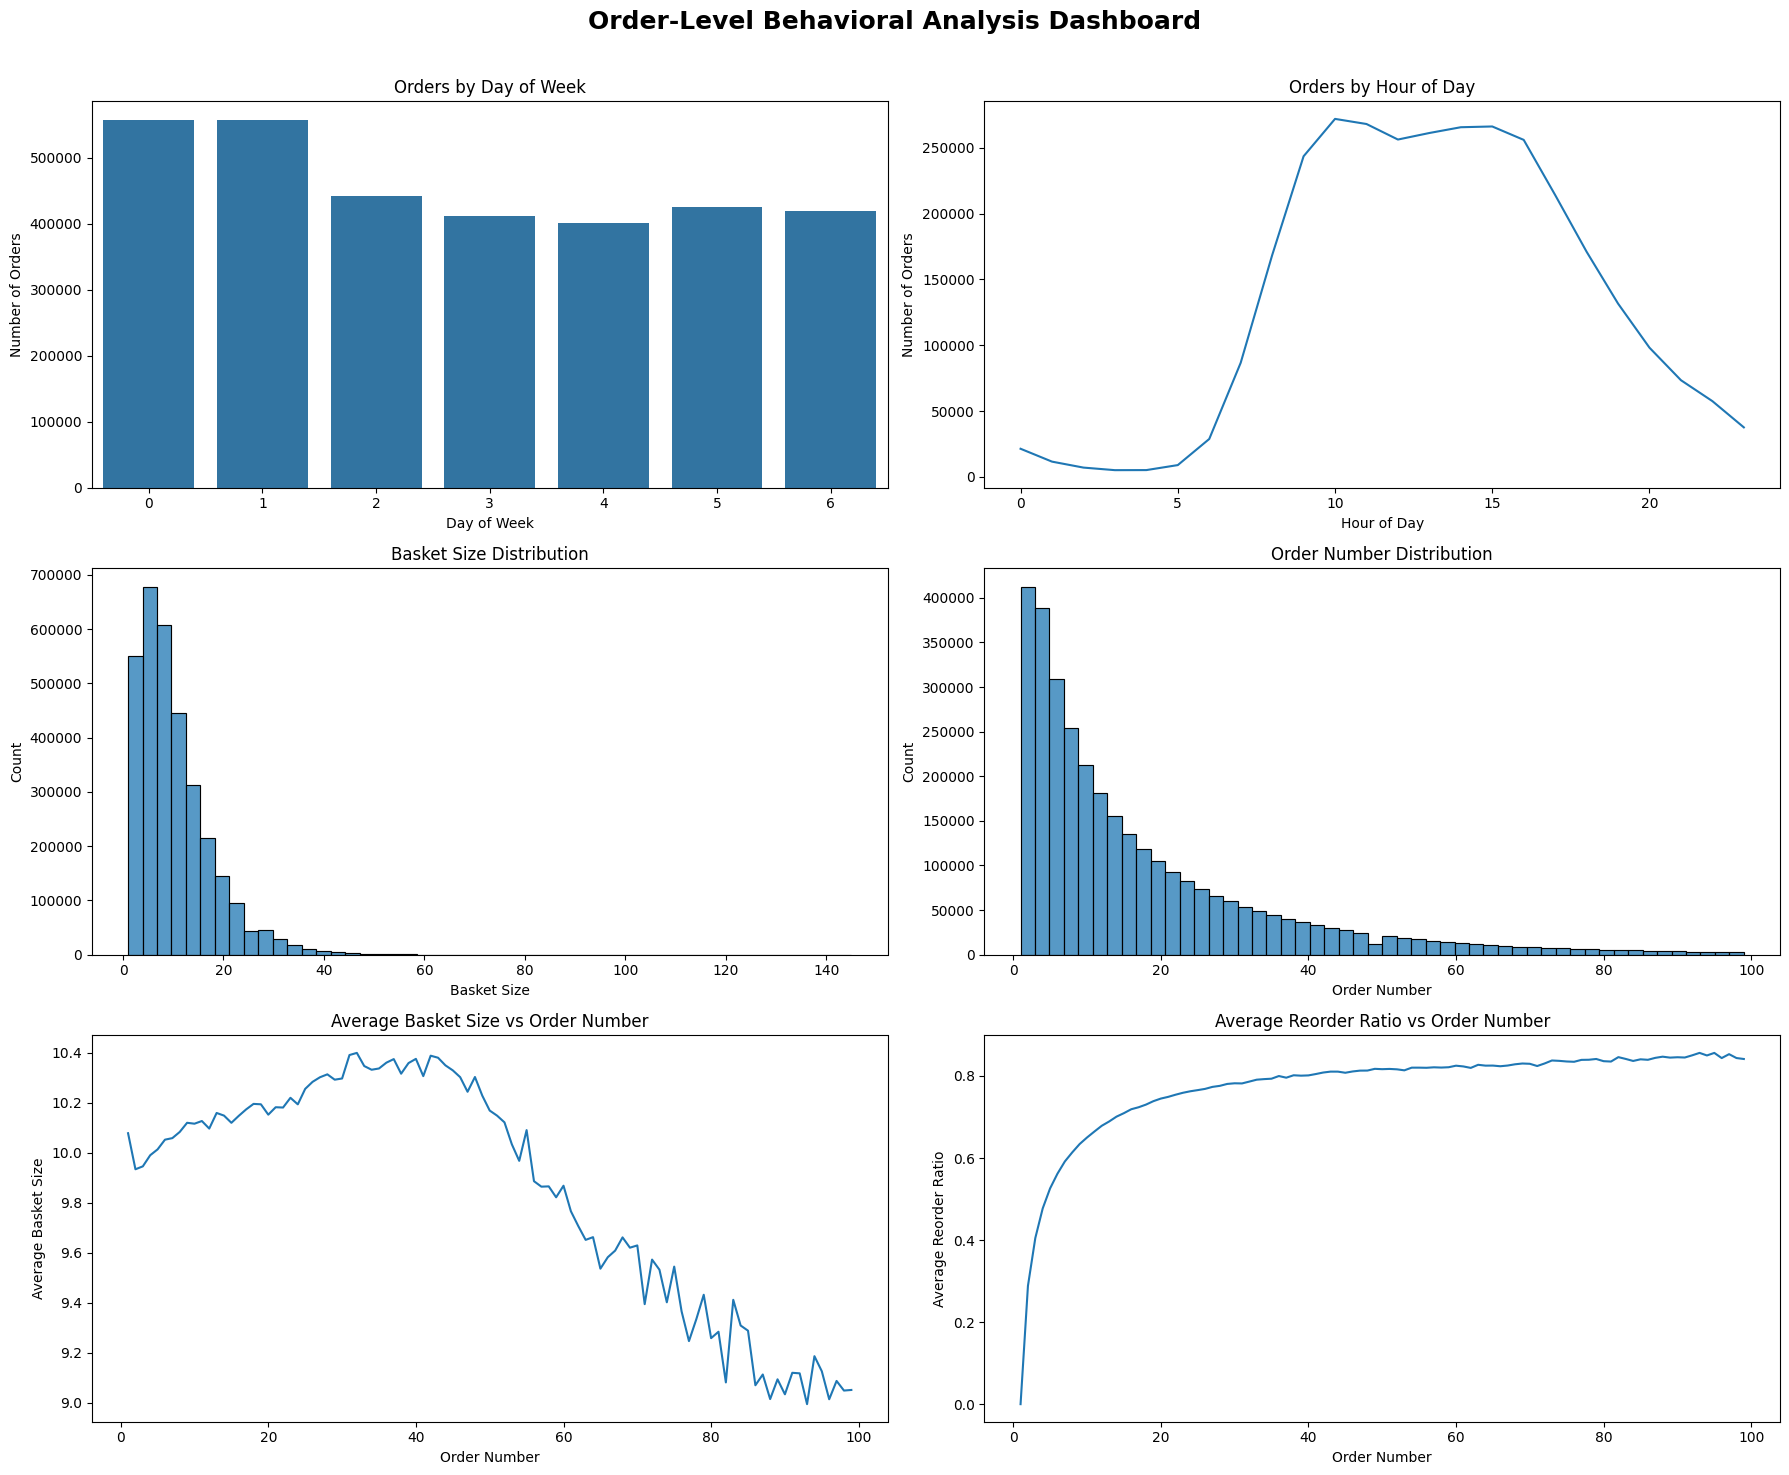

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create dashboard
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 15)
)

axes = axes.flatten()

# --------------------------------------------------
# 1. Orders by Day of Week
# --------------------------------------------------

orders_by_day = (
    order_df["order_dow"]
    .value_counts()
    .sort_index()
)

sns.barplot(
    x=orders_by_day.index,
    y=orders_by_day.values,
    ax=axes[0]
)

axes[0].set_title("Orders by Day of Week")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Orders")

# --------------------------------------------------
# 2. Orders by Hour of Day
# --------------------------------------------------

orders_by_hour = (
    order_df["order_hour_of_day"]
    .value_counts()
    .sort_index()
)

sns.lineplot(
    x=orders_by_hour.index,
    y=orders_by_hour.values,
    ax=axes[1]
)

axes[1].set_title("Orders by Hour of Day")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Number of Orders")

# --------------------------------------------------
# 3. Basket Size Distribution
# --------------------------------------------------

sns.histplot(
    order_df["basket_size"],
    bins=50,
    ax=axes[2]
)

axes[2].set_title("Basket Size Distribution")
axes[2].set_xlabel("Basket Size")
axes[2].set_ylabel("Count")

# --------------------------------------------------
# 4. Order Number Distribution
# --------------------------------------------------

sns.histplot(
    order_df["order_number"],
    bins=50,
    ax=axes[3]
)

axes[3].set_title("Order Number Distribution")
axes[3].set_xlabel("Order Number")
axes[3].set_ylabel("Count")

# --------------------------------------------------
# 5. Average Basket Size vs Order Number
# --------------------------------------------------

basket_evolution = (
    order_df
    .groupby("order_number")["basket_size"]
    .mean()
)

sns.lineplot(
    x=basket_evolution.index,
    y=basket_evolution.values,
    ax=axes[4]
)

axes[4].set_title("Average Basket Size vs Order Number")
axes[4].set_xlabel("Order Number")
axes[4].set_ylabel("Average Basket Size")

# --------------------------------------------------
# 6. Average Reorder Ratio vs Order Number
# --------------------------------------------------

reorder_evolution = (
    order_df
    .groupby("order_number")["reorder_ratio"]
    .mean()
)

sns.lineplot(
    x=reorder_evolution.index,
    y=reorder_evolution.values,
    ax=axes[5]
)

axes[5].set_title("Average Reorder Ratio vs Order Number")
axes[5].set_xlabel("Order Number")
axes[5].set_ylabel("Average Reorder Ratio")

# --------------------------------------------------
# Dashboard Formatting
# --------------------------------------------------

plt.suptitle(
    "Order-Level Behavioral Analysis Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

# Order-Level Behavioral Analysis

The order-level behavioral dashboard provides insights into customer shopping patterns, purchasing behavior, loyalty development, and lifecycle progression across more than 3.2 million orders.

---

## 1. Orders by Day of Week

Order volume varies across the week, with Days 0 and 1 exhibiting the highest activity levels.

### Key Insights

- Days 0 and 1 record the largest number of orders.
- Remaining days show relatively stable order volumes.
- Weekly seasonality is evident in customer purchasing behavior.

### Business Implications

- Inventory allocation should account for weekly demand spikes.
- Promotional campaigns may achieve greater reach during peak shopping days.
- Workforce and fulfillment planning should align with expected order volumes.

---

## 2. Orders by Hour of Day

Order activity exhibits a strong daily pattern.

### Key Insights

- Shopping activity is minimal during late-night and early-morning hours.
- Order volume begins increasing significantly after 7 AM.
- Peak shopping activity occurs between 10 AM and 4 PM.
- Order volume steadily declines after late afternoon.

### Business Implications

- Customers primarily shop during daytime hours.
- Marketing notifications and promotions can be timed around peak activity windows.
- Operational resources should be optimized for midday demand.

---

## 3. Basket Size Distribution

Basket size demonstrates a strongly right-skewed distribution.

### Key Insights

- Most orders contain fewer than 20 products.
- Basket sizes between 5 and 15 products are the most common.
- A small subset of customers places exceptionally large orders.

### Business Implications

- Most shopping missions are focused and relatively small.
- Large-basket customers represent high-value segments.
- Cross-selling and bundling strategies may increase average basket size.

---

## 4. Order Number Distribution

The number of orders decreases steadily as order number increases.

### Key Insights

- Early customer orders are significantly more common than later orders.
- The customer population gradually decreases as customers progress through their lifecycle.
- Only a small fraction of customers reach very high order counts.

### Business Implications

- Customer retention plays a critical role in long-term platform growth.
- Early-stage customer engagement should be prioritized.
- High-order-number customers represent the most loyal customer segment.

---

## 5. Average Basket Size vs Order Number

The average basket size evolves throughout the customer lifecycle.

### Key Insights

- Basket size gradually increases during the first 30–40 orders.
- Peak basket size occurs around Order 35–40.
- Basket size declines steadily after this point.

### Customer Lifecycle Interpretation

#### Exploration Phase (Orders 1–20)

- Customers become familiar with the platform.
- Basket sizes increase gradually.

#### Expansion Phase (Orders 20–40)

- Customer engagement reaches its highest level.
- Basket sizes peak as customers explore more products.

#### Optimization Phase (Orders 40+)

- Customers become more efficient shoppers.
- Orders become smaller and more focused.

### Business Implications

- Mature customers tend to purchase more strategically.
- Product discovery initiatives may be most effective during the early and middle stages of the customer lifecycle.

---

## 6. Average Reorder Ratio vs Order Number

This is the most significant finding in the analysis.

### Key Insights

The average reorder ratio increases rapidly with customer experience:

| Order Number | Average Reorder Ratio |
|--------------|----------------------|
| 1 | ~0% |
| 10 | ~65% |
| 20 | ~75% |
| 50 | ~82% |
| 100 | ~85% |

### Interpretation

As customers place more orders, they increasingly purchase products they have previously bought.

Early orders contain substantial exploration and experimentation, whereas later orders primarily consist of replenishment purchases.

### Business Implications

- Customer loyalty strengthens significantly over time.
- Purchasing behavior becomes increasingly predictable.
- Repeat purchasing becomes the dominant shopping behavior for long-term customers.

### Strategic Applications

These findings support:

- Personalized recommendation systems
- Product replenishment suggestions
- Customer retention initiatives
- Inventory forecasting
- Customer lifetime value analysis

---

# Overall Findings

The order-level analysis reveals a clear customer lifecycle pattern:

### Stage 1: Exploration

- Customers experiment with products and categories.
- Basket sizes increase steadily.
- Reorder ratios remain relatively low.

### Stage 2: Expansion

- Customer engagement reaches its peak.
- Basket sizes become largest.
- Product discovery remains active.

### Stage 3: Loyalty and Optimization

- Customers become highly loyal.
- Reorder ratios exceed 80%.
- Shopping behavior becomes more predictable and focused.

---

# Conclusion

The order-level feature store captures several critical dimensions of customer behavior:

- Shopping timing and seasonality
- Basket composition and order size
- Customer lifecycle progression
- Loyalty development through repeat purchases

The analysis suggests that customers initially explore the platform, gradually expand their purchasing behavior, and ultimately transition into highly loyal shoppers whose orders primarily consist of repeat purchases. These insights provide a strong foundation for customer intelligence, recommendation systems, demand forecasting, inventory planning, and business analytics applications within the CommerceAI platform.